In [ ]:
!pip install kagglehub

import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import sklearn.metrics as metrics

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2


In [ ]:
# Download Dermnet Dataset
path = kagglehub.dataset_download("shubhamgoel27/dermnet")
print("Dataset path:", path)

Using Colab cache for faster access to the 'dermnet' dataset.
Dataset path: /kaggle/input/dermnet


In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Load dataset
img_size = (128, 128)
batch_size = 16

train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    path + "/train",
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    path + "/test",
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

# Get class names BEFORE chaining shuffle/prefetch
class_names = train_ds_raw.class_names
print("Classes found:", class_names)

# Get size of dataset
train_size = tf.data.experimental.cardinality(train_ds_raw).numpy()
val_size = int(0.2 * train_size)
train_size = train_size - val_size

# Split dataset
val_ds_raw = train_ds_raw.take(val_size)
train_ds_raw_split = train_ds_raw.skip(val_size)

# Apply shuffle & prefetch
train_ds = train_ds_raw_split.shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds_raw.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds_raw.prefetch(tf.data.AUTOTUNE)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

# Apply shuffle and prefetch for efficient training
train_ds = train_ds_raw.shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds_raw.prefetch(tf.data.AUTOTUNE)

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_names),
    y=class_names
)

# Convert class weights to dictionary
class_weights_dict = dict(enumerate(class_weights))

# Print class weights for reference
print("Class weights:", class_weights_dict)


Found 15557 files belonging to 23 classes.
Found 4002 files belonging to 23 classes.
Classes found: ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives', 'Vascular Tumors', 'Vasculitis Photos', 'Warts Molluscum and other Viral Inf

In [ ]:
#Callback to save the best model
callbacks_list = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),

    tf.keras.callbacks.ModelCheckpoint(
        filepath='mbNetV2model2.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10,verbose=1)
]

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Model

IMG_SIZE = 128

# Load the MobileNetV2 model pre-trained on ImageNet
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze the early layers of the base model
for layer in base_model.layers[:10]:
    layer.trainable = False

# Build a new model on top of the pre-trained base
inputs = base_model.input
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(train_ds,
                    epochs=15,
                    validation_data=val_ds,
                    class_weight=class_weights_dict,
                    callbacks=[callbacks_list])

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:517: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Epoch 1/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.2034 - loss: 2.7945
Epoch 1: val_accuracy improved from -inf to 0.08827, saving model to mbNetV2model2.keras
973/973 ━━━━━━━━━━━━━━━━━━━━ 754s 685ms/step - accuracy: 0.2034 - loss: 2.7943 - val_accuracy: 0.0883 - val_loss: 689.6028 - learning_rate: 0.0010
Epoch 2/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.3122 - loss: 2.3292
Epoch 2: val_accuracy improved from 0.08827 to 0.20264, saving model to mbNetV2model2.keras
973/973 ━━━━━━━━━━━━━━━━━━━━ 734s 679ms/step - accuracy: 0.3122 - loss: 2.3292 - val_accuracy: 0.2026 - val_loss: 5.1731 - learning_rate: 0.0010
Epoch 3/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.3831 - loss: 2.1074
Epoch 3: val_accuracy improved from 0.20264 to 0.31637, saving model to mbNetV2model2.keras
973/973 ━━━━━━━━━━━━━━━━━━━━ 741s 685ms/step - accuracy: 0.3831 - loss: 2.1074 - val_accuracy: 0.3164 - val_loss: 7.0297 - learning_rate: 0.0010
Epoch 4/15
973/973 ━━━━━━━

In [ ]:
model.load_weights('mbNetV2model2.keras')

In [ ]:
import json

# Save labels
with open("mobilenetv3_labels.json", "w") as f:
    json.dump(class_names, f)

# Save trained model
model.save("skin_mobilenetv3.h5")


In [ ]:
# Save trained model in keras format
model.save("skin_mobilenetv3.keras")

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

251/251 ━━━━━━━━━━━━━━━━━━━━ 49s 192ms/step - accuracy: 0.5197 - loss: 2.4821
Test Accuracy: 52.12%


Saving face.jpg to face.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted Class: Acne and Rosacea Photos (Confidence: 0.58)


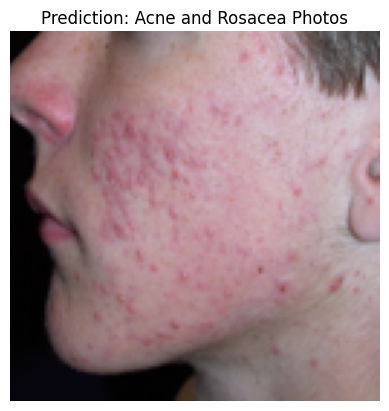

In [ ]:
# 11: Prediction Demo
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()

for fn in uploaded.keys():
    # Load and preprocess image
    img_path = fn
    img = Image.open(img_path).convert("RGB")
    img = img.resize((128, 128))   # resize to model input size

    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    # Predict
    preds = model.predict(x)
    predicted_class = class_names[np.argmax(preds)]
    confidence = np.max(preds)

    print(f"Predicted Class: {predicted_class} (Confidence: {confidence:.2f})")

    # Show image
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}")
    plt.axis("off")
    plt.show()


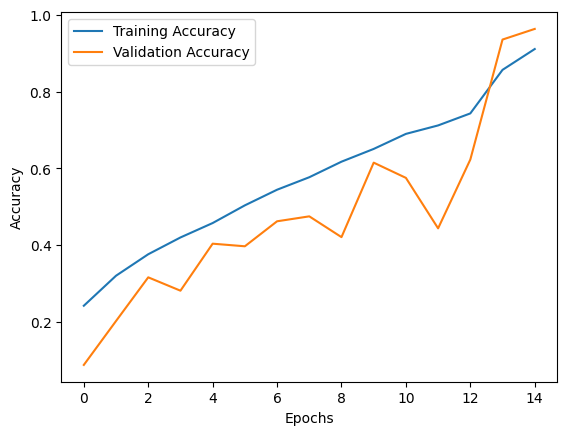

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

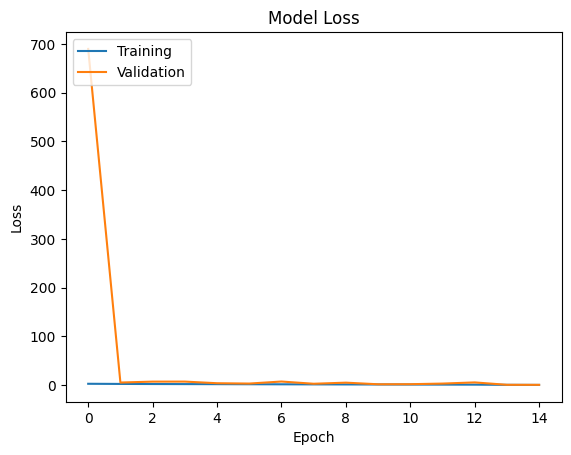

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()